In [1]:
import os
import subprocess
import geopandas
import xarray as xr
import numpy as np
import rioxarray
import datetime as dt
from rasterio.enums import Resampling
from shapely.geometry import box, Point
import pandas as pd
from rasterio.transform import Affine, xy
from rasterio.features import shapes
import matplotlib.pyplot as plt
from shapely.geometry import LineString
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from matplotlib.animation import FuncAnimation, FFMpegWriter
from shapely.ops import substring
from scipy.ndimage import gaussian_filter1d
from matplotlib.patches import FancyBboxPatch


In [2]:
projectDir = "/Users/rfk471/Dropbox/elevation-canada"

project_crs = "EPSG:3413"

experiment = "v1-0"

region_ids = ["01","02","03","04","05","06"]

region_ids_south = ["07","08","09","10","11","12","13","14","15"]

In [3]:
dataDir = f"{projectDir}/data/initial/RGI"

In [4]:
def compute_differences(df, ref_idx=0):
    """
    Convert elevation profiles to differences relative to a
    user-specified reference profile.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing elevation profiles.

    ref_idx : int, default=0
        Positional index of the profile to use as reference.
        For example:
        0 = first profile
        1 = second profile
        4 = fifth profile.

    Returns
    -------
    df_anom : pandas.DataFrame
        Elevation differences relative to the reference profile.
    """

    df_anom = pd.DataFrame(index=df.index)

    for col in df.columns:

        # --- Select reference profile ---
        ref_profile = df[col].iloc[ref_idx]

        # --- Compute differences ---
        anomalies = []

        for t in df.index:
            prof = df.loc[t, col]

            if prof is None or (
                isinstance(prof, float) and np.isnan(prof)
            ):
                anomalies.append(np.nan)
            else:
                anomalies.append(prof - ref_profile)

        df_anom[col] = anomalies

    return df_anom

In [5]:
def extract_line_timeseries_segments(glacier_gdf, udem, cs):
    """
    Extract elevation profiles along a glacier line and compute dh/dt per point.
    Returns:
    - gdf_segments: GeoDataFrame of line segments with dh/dt for each product
    - df: pandas DataFrame with full elevation profiles along line for each time step
    - distances: array of distances along the line
    """
    line = glacier_gdf.geometry.iloc[0]
    n_points = np.int64(np.floor(glacier_gdf["length_m"].iloc[0]/50))

    # --- Sample points along line ---
    distances = np.linspace(0, line.length, n_points)


    points = [line.interpolate(d) for d in distances]
    xs = np.array([p.x for p in points])
    ys = np.array([p.y for p in points])

    # --- Sampling function ---
    def sample_along_line(da):
        da = da.squeeze(drop=True)
        if "time" not in da.dims:
            da = da.expand_dims(time=[pd.NaT])
        sampled = da.interp(x=("points", xs), y=("points", ys),method='linear')
        return sampled  # (time, points)

    # --- Extract profiles ---
    udem_prof = sample_along_line(udem)
    cs_prof = sample_along_line(cs)

    # --- Convert to pandas (arrays per timestep) ---
    def to_series_of_arrays(da):
        times = pd.to_datetime(da["time"].values)
        profiles = [da.sel(time=t).values.squeeze() for t in times]
        return pd.Series(profiles, index=times)

    s_udem = to_series_of_arrays(udem_prof)
    s_cs = to_series_of_arrays(cs_prof)

    df = pd.concat(
        [s_udem.rename("udem"),
         s_cs.rename("cs")],
        axis=1
    ).sort_index()

    # --- Compute dh/dt along profile ---
    def compute_spatial_trend(da):
        arr = da.transpose("time", "points").values
        times = pd.to_datetime(da["time"].values)
        valid_mask = ~np.all(np.isnan(arr), axis=1)
        arr = arr[valid_mask]
        times = times[valid_mask]

        if len(times) < 2:
            return np.full(arr.shape[1], np.nan)

        t_years = times.year + (times.dayofyear - 1) / 365.25
        dhdt = np.full(arr.shape[1], np.nan)
        for i in range(arr.shape[1]):
            y = arr[:, i]
            mask = ~np.isnan(y)
            if np.sum(mask) < 2:
                continue
            dhdt[i] = np.polyfit(t_years[mask], y[mask], 1)[0]
        return dhdt

    dhdt_udem = compute_spatial_trend(udem_prof)
    dhdt_cs = compute_spatial_trend(cs_prof)

    # --- Build segments for continuous coloring ---
    segments = []
    udem_vals = []
    cs_vals = []

    for i in range(n_points - 1):
        seg = LineString([line.interpolate(distances[i]),
                          line.interpolate(distances[i + 1])])
        segments.append(seg)
        udem_vals.append(dhdt_udem[i])
        cs_vals.append(dhdt_cs[i])

    gdf_segments = geopandas.GeoDataFrame({
        "geometry": segments,
        "udem_dhdt": udem_vals,
        "cs_dhdt": cs_vals
    }, crs=glacier_gdf.crs)

    return gdf_segments, df, distances

In [6]:
def plot_surging_glacier(df_anom,distances,udem_masked_rio_trend,glacier,glacierline,glaciername,glaciernameshort,highlight_dates,experiment,projectDir):
    # -----------------------------
    # Prepare anomaly data
    # -----------------------------
    data = df_anom["udem"].dropna()

    times = data.index
    profiles = data.values

    time_nums = mdates.date2num(times)

    norm = mcolors.Normalize(
        vmin=time_nums.min(),
        vmax=time_nums.max()
    )

    cmap = cm.hot

    distance_from_front = distances[-1] - distances


    # -----------------------------
    # Create figure with GridSpec
    # -----------------------------
    fig = plt.figure(figsize=(8, 10))

    gs = gridspec.GridSpec(
        nrows=3,
        ncols=1,
        height_ratios=[1, 1, 1],  # top plot spans first 2 rows
        hspace=0.25
    )


    # =============================
    # Top plot (raster)
    # =============================
    ax1 = fig.add_subplot(gs[0:2])

    udem_masked_rio_trend.plot(
        ax=ax1,
        cmap="RdBu",
        vmin=-10,
        vmax=10,
        cbar_kwargs={"label": "Elevation change [m]"}
    )

    glacier.boundary.plot(ax=ax1, color="k")
    glacierline.plot(ax=ax1, linestyle="--", color="k")

    ax1.set_title(glaciername)
    ax1.set_xlim(
        glacier.geometry.total_bounds[0] - 1000,
        glacier.geometry.total_bounds[2] + 1000
    )
    ax1.set_ylim(
        glacier.geometry.total_bounds[1] - 1000,
        glacier.geometry.total_bounds[3] + 1000
    )

    ax1.set_aspect("equal", adjustable="box", anchor="C")
    ax1.set_xticks([])
    ax1.set_yticks([])
    ax1.set_xlabel("")
    ax1.set_ylabel("")

    # =============================
    # Bottom plot (profiles)
    # =============================
    ax2 = fig.add_subplot(gs[2])
    ax2.set_facecolor("lightgrey")

    # for t_num, profile in zip(time_nums, profiles):
    #     color = cmap(norm(t_num))
    #     ax2.plot(distances, profile, color=color, alpha=0.9)

    for t in df_anom.index:

        profile = df_anom.loc[t, "udem"]

        if profile is None or (
            isinstance(profile, float) and np.isnan(profile)
        ):
            continue

        if pd.Timestamp(t) in highlight_dates:
            linewidth = 1.5
            zorder = 5
        else:
            linewidth = 0.35
            zorder = 1

        color = cmap(norm(mdates.date2num(pd.Timestamp(t))))

        ax2.plot(
            distance_from_front,
            profile,
            color=color,
            linewidth=linewidth,
            alpha=0.9,
            zorder=zorder,
        )
    
    ax2.set_xlim(distances[-1],0)

    ax1.text(0.03,0.94,"(a)",fontweight='bold',transform=ax1.transAxes,fontsize=10,bbox=dict(facecolor="white",alpha=0.6,edgecolor="none",boxstyle="square,pad=0.15"))
    ax2.text(0.03,0.90,"(b)",fontweight='bold',transform=ax2.transAxes,fontsize=10,bbox=dict(facecolor="white",alpha=0.6,edgecolor="none",boxstyle="square,pad=0.15"))

    # Colorbar for profiles
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cbar = plt.colorbar(sm, ax=ax2)
    cbar.set_label("Year")

    cbar.ax.yaxis.set_major_locator(mdates.YearLocator())
    cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    ax2.set_xlabel("Distance from glacier front [m]")
    ax2.set_ylabel("Elevation change [m]")
    #ax2.set_title("U-DEM Δh profiles")

    ax2.grid(True)
    min_val = np.nanmin(np.concatenate(df_anom["udem"].dropna().values))
    max_val = np.nanmax(np.concatenate(df_anom["udem"].dropna().values))

    min_val = np.floor(min_val / 5) * 5
    max_val = np.ceil(max_val / 5) * 5
    ax2.set_ylim(min_val , max_val)
    fig.savefig(f"{projectDir}/figures/{experiment}_surging_{glaciernameshort}.png",dpi=300,bbox_inches="tight")

In [7]:
RGI_n = geopandas.read_file(dataDir+"/RGI2000-v7.0-G-03_arctic_canada_north/RGI2000-v7.0-G-03_arctic_canada_north.shp").to_crs(project_crs)
RGI_s = geopandas.read_file(dataDir+"/RGI2000-v7.0-G-04_arctic_canada_south/RGI2000-v7.0-G-04_arctic_canada_south.shp").to_crs(project_crs)
RGIL_n = geopandas.read_file(dataDir+"/RGI2000-v7.0-L-03_arctic_canada_north/RGI2000-v7.0-L-03_arctic_canada_north.shp").to_crs(project_crs)
RGIL_s = geopandas.read_file(dataDir+"/RGI2000-v7.0-L-04_arctic_canada_south/RGI2000-v7.0-L-04_arctic_canada_south.shp").to_crs(project_crs)

In [8]:
RGI_n_possible = RGI_n[RGI_n["surge_type"]==1]
RGI_n_probable = RGI_n[RGI_n["surge_type"]==2]
RGI_n_observed = RGI_n[RGI_n["surge_type"]==3]
RGIL_n_observed = RGIL_n[RGIL_n["rgi_g_id"].isin(RGI_n_observed["rgi_id"])]

RGI_s_possible = RGI_s[RGI_s["surge_type"]==1]
RGI_s_probable = RGI_s[RGI_s["surge_type"]==2]
RGI_s_observed = RGI_s[RGI_s["surge_type"]==3]
RGIL_s_observed = RGIL_s[RGIL_s["rgi_g_id"].isin(RGI_s_observed["rgi_id"])]

In [9]:
iceberg = RGI_n_observed[RGI_n_observed["glac_name"] == 'Iceberg']
iceberg_lines = RGIL_n[RGIL_n["rgi_g_id"].isin(iceberg["rgi_id"])]
iceberg_line = iceberg_lines[iceberg_lines["length_m"]>60000]

In [10]:
region_id = "01"
mask_dir = f"{projectDir}/data/interim/region-{region_id}/masks/"
mask = rioxarray.open_rasterio(os.path.join(mask_dir,'mask_100m.tif')).squeeze()

udem = xr.load_dataset(f"{projectDir}/data/final/udem_region-{region_id}_{experiment}_all.nc")["udem"]
udem_masked = udem.where(mask==1)
udem_masked_rio = udem_masked.rio.write_crs(project_crs)


cs = xr.load_dataset(f"{projectDir}/data/interim/region-{region_id}/cryoswath_seasonal/cs_raw_gathered_region-{region_id}.nc")["cs-elevation"]
common_time = np.intersect1d(udem.time.values, cs.time.values)
cs = cs.sel(time=common_time)
cs_masked = cs.where(mask==1)
cs_masked_rio = cs_masked.rio.write_crs(project_crs)


glacier_out, df,distances = extract_line_timeseries_segments(iceberg_line, udem_masked, cs_masked)
df_anom = compute_differences(df,ref_idx=2)

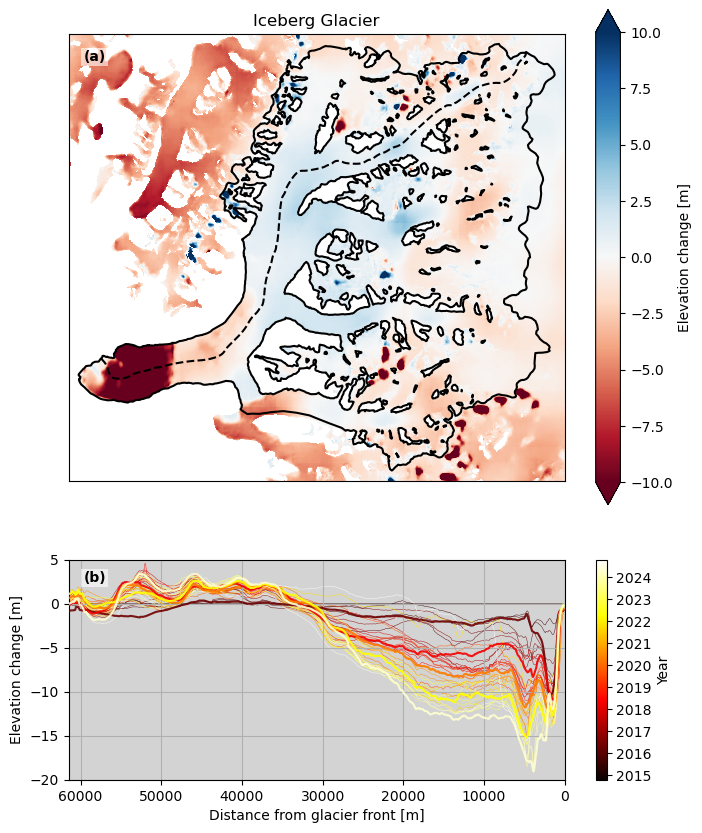

In [11]:
# Dates to highlight in the lower panel
highlight_dates = pd.to_datetime([
    "2016-04-15",
    "2018-04-15",
    "2020-04-15",
    "2022-04-15",
    "2024-04-15",
])

udem_ref = udem_masked_rio.sel(time = udem_masked_rio.time.values[-1]) - udem_masked_rio.sel(time = udem_masked_rio.time.values[2])

plot_surging_glacier(df_anom,distances,udem_ref,iceberg,iceberg_line,"Iceberg Glacier","iceberg",highlight_dates,experiment,projectDir)


In [12]:
mittie_id = "RGI2000-v7.0-G-03-04910"
mittie = RGI_n_observed[RGI_n_observed["rgi_id"] == mittie_id]
mittie_lines = RGIL_n[RGIL_n["rgi_g_id"].isin(mittie["rgi_id"])]

In [13]:
mittie_line = mittie_lines[mittie_lines["length_m"]==54194]

In [14]:
region_id = "05"
mask_dir = f"{projectDir}/data/interim/region-{region_id}/masks/"
mask = rioxarray.open_rasterio(os.path.join(mask_dir,'mask_100m.tif')).squeeze()

udem = xr.load_dataset(f"{projectDir}/data/final/udem_region-{region_id}_{experiment}_all.nc")["udem"]
udem_masked = udem.where(mask==1)
udem_masked_rio = udem_masked.rio.write_crs(project_crs)

cs = xr.load_dataset(f"{projectDir}/data/interim/region-{region_id}/cryoswath_seasonal/cs_raw_gathered_region-{region_id}.nc")["cs-elevation"]
common_time = np.intersect1d(udem.time.values, cs.time.values)
cs = cs.sel(time=common_time)
cs_masked = cs.where(mask==1)
cs_masked_rio = cs_masked.rio.write_crs(project_crs)

glacier_out, df,distances = extract_line_timeseries_segments(mittie_line, udem_masked, cs_masked)
df_anom = compute_differences(df,ref_idx=0)

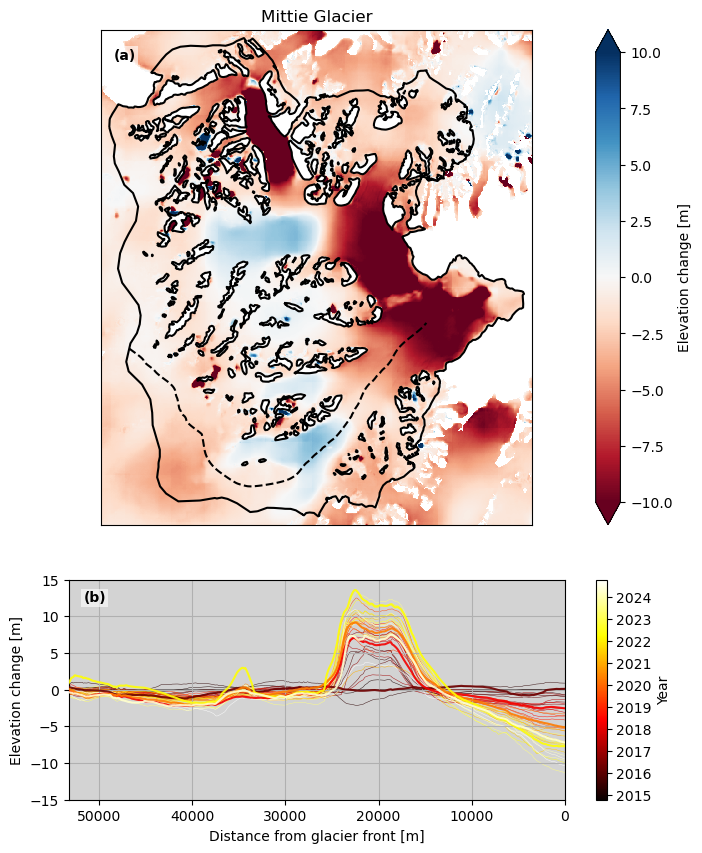

In [15]:
highlight_dates = pd.to_datetime([
    "2016-04-15",
    "2018-04-15",
    "2020-04-15",
    "2022-04-15",
    "2024-04-15",
])

udem_ref = udem_masked_rio.sel(time = udem_masked_rio.time.values[-1]) - udem_masked_rio.sel(time = udem_masked_rio.time.values[0])

plot_surging_glacier(df_anom,distances,udem_ref,mittie,mittie_line,"Mittie Glacier","mittie",highlight_dates,experiment,projectDir)

In [16]:
def plot_surging_glacier_2line(
    df_anom1,
    distances1,
    df_anom2,
    distances2,
    udem_masked_rio_trend,
    glacier,
    glacierline1,
    glacierline2,
    glaciername,
    glaciernameshort,
    highlight_dates,
    experiment,
    projectDir
):

    # -----------------------------
    # Prepare common time colour scale
    # -----------------------------
    times1 = pd.to_datetime(df_anom1["udem"].dropna().index)
    times2 = pd.to_datetime(df_anom2["udem"].dropna().index)

    all_times = times1.union(times2)

    time_nums = mdates.date2num(all_times)

    norm = mcolors.Normalize(
        vmin=time_nums.min(),
        vmax=time_nums.max()
    )

    cmap = cm.hot

    distance_from_front1 = distances1[-1] - distances1
    distance_from_front2 = distances2[-1] - distances2

    # -----------------------------
    # Common y limits for profiles
    # -----------------------------
    values1 = np.concatenate(df_anom1["udem"].dropna().values)
    values2 = np.concatenate(df_anom2["udem"].dropna().values)

    min_val = np.nanmin(
        np.concatenate([values1, values2])
    )
    max_val = np.nanmax(
        np.concatenate([values1, values2])
    )

    min_val = np.floor(min_val / 5) * 5
    max_val = np.ceil(max_val / 5) * 5

    # -----------------------------
    # Create figure
    # -----------------------------
    fig = plt.figure(figsize=(12, 5))

    gs = gridspec.GridSpec(
        nrows=2,
        ncols=2,
        width_ratios=[1.1, 1],
        height_ratios=[1, 1],
        wspace=0.25,
        hspace=0.22
    )

    # =============================
    # Panel (a): raster
    # spans both rows in first column
    # =============================
    ax1 = fig.add_subplot(gs[:, 0])

    udem_masked_rio_trend.plot(
        ax=ax1,
        cmap="RdBu",
        vmin=-10,
        vmax=10,
        cbar_kwargs={"label": "Elevation change [m]"}
    )

    glacier.boundary.plot(
        ax=ax1,
        color="k"
    )

    glacierline1.plot(
        ax=ax1,
        linestyle="--",
        color="k",
        linewidth=1.2
    )

    glacierline2.plot(
        ax=ax1,
        linestyle="--",
        color="k",
        linewidth=1.2
    )

    ax1.set_title(glaciername)

    ax1.set_xlim(
        glacier.geometry.total_bounds[0] - 1000,
        glacier.geometry.total_bounds[2] + 1000
    )

    ax1.set_ylim(
        glacier.geometry.total_bounds[1] - 1000,
        glacier.geometry.total_bounds[3] + 1000
    )

    ax1.set_aspect(
        "equal",
        adjustable="box",
        anchor="C"
    )

    ax1.set_xticks([])
    ax1.set_yticks([])
    ax1.set_xlabel("")
    ax1.set_ylabel("")

    ax1.text(
        0.03,
        0.94,
        "(a)",
        fontweight="bold",
        transform=ax1.transAxes,
        fontsize=10,
        bbox=dict(
            facecolor="white",
            alpha=0.6,
            edgecolor="none",
            boxstyle="square,pad=0.15"
        )
    )
    ax1.annotate('Main trunk (c)', xy=(-540500, -764000), xytext=(-530000, -750000),fontsize=8,arrowprops=dict(arrowstyle='Simple,tail_width=0.2,head_width=1,head_length=1',facecolor='white',edgecolor='black',linewidth=0.8))
    ax1.annotate('Main tributary (b)', xy=(-526000, -765000), xytext=(-526000, -758000),fontsize=8,arrowprops=dict(arrowstyle='Simple,tail_width=0.2,head_width=1,head_length=1',facecolor='white',edgecolor='black',linewidth=0.8))
    
    # Scale bar background box
    box = FancyBboxPatch(
        (-524000, -785000),   
        7500,                 
        3500,                 
        boxstyle="round,pad=0.01",
        facecolor="white",
        edgecolor="black",
        linewidth=0.8,
        zorder=9
    )

    ax1.add_patch(box)

    # Scale bar
    ax1.plot(
        [-518000, -523000],
        [-783900, -783900],
        color="k",
        linewidth=2,
        zorder=10
    )

    # Label
    ax1.text(
        -520500,
        -783000,
        "5 km",
        fontsize=8,
        ha="center",
        va="center",
        zorder=10
    )
    
    
    # =============================
    # Panel (b): profile line 1
    # top right
    # =============================
    ax2 = fig.add_subplot(gs[0, 1])

    ax2.set_facecolor("lightgrey")

    for t in df_anom1.index:

        profile = df_anom1.loc[t, "udem"]

        if profile is None or (
            isinstance(profile, float)
            and np.isnan(profile)
        ):
            continue

        t_timestamp = pd.Timestamp(t)

        if t_timestamp in highlight_dates:
            linewidth = 1.5
            zorder = 5
        else:
            linewidth = 0.35
            zorder = 1

        color = cmap(
            norm(
                mdates.date2num(t_timestamp)
            )
        )

        ax2.plot(
            distance_from_front1,
            profile,
            color=color,
            linewidth=linewidth,
            alpha=0.9,
            zorder=zorder
        )

    ax2.set_xlim(distances1[-1], 0)
    ax2.set_ylim(min_val, max_val)

    ax2.set_ylabel(
        "Elevation change [m]"
    )

    ax2.grid(True)

    ax2.text(
        0.03,
        0.88,
        "(b)",
        fontweight="bold",
        transform=ax2.transAxes,
        fontsize=10,
        bbox=dict(
            facecolor="white",
            alpha=0.6,
            edgecolor="none",
            boxstyle="square,pad=0.15"
        )
    )

    # =============================
    # Panel (c): profile line 2
    # bottom right
    # =============================
    ax3 = fig.add_subplot(
        gs[1, 1],
        sharex=ax2,
        sharey=ax2
    )

    ax3.set_facecolor("lightgrey")

    for t in df_anom2.index:

        profile = df_anom2.loc[t, "udem"]

        if profile is None or (
            isinstance(profile, float)
            and np.isnan(profile)
        ):
            continue

        t_timestamp = pd.Timestamp(t)

        if t_timestamp in highlight_dates:
            linewidth = 1.5
            zorder = 5
        else:
            linewidth = 0.35
            zorder = 1

        color = cmap(
            norm(
                mdates.date2num(t_timestamp)
            )
        )

        ax3.plot(
            distance_from_front2,
            profile,
            color=color,
            linewidth=linewidth,
            alpha=0.9,
            zorder=zorder
        )

    ax3.set_xlim(distances1[-1], 0)
    ax3.set_ylim(min_val, max_val)

    ax3.set_xlabel(
        "Distance from glacier front [m]"
    )

    ax3.set_ylabel(
        "Elevation change [m]"
    )

    ax3.grid(True)

    ax3.text(
        0.03,
        0.88,
        "(c)",
        fontweight="bold",
        transform=ax3.transAxes,
        fontsize=10,
        bbox=dict(
            facecolor="white",
            alpha=0.6,
            edgecolor="none",
            boxstyle="square,pad=0.15"
        )
    )

    # Hide x tick labels on upper profile
    plt.setp(
        ax2.get_xticklabels(),
        visible=False
    )

    # =============================
    # Shared colourbar for profiles
    # =============================
    sm = cm.ScalarMappable(
        norm=norm,
        cmap=cmap
    )

    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=[ax2, ax3],
        pad=0.03
    )

    cbar.set_label("Year")

    cbar.ax.yaxis.set_major_locator(
        mdates.YearLocator()
    )

    cbar.ax.yaxis.set_major_formatter(
        mdates.DateFormatter("%Y")
    )

    # -----------------------------
    # Save
    # -----------------------------
    fig.savefig(
        f"{projectDir}/figures/"
        f"{experiment}_surging_{glaciernameshort}.png",
        dpi=300,
        bbox_inches="tight"
    )

In [17]:
chapman = RGI_n_observed[RGI_n_observed["glac_name"] == 'Chapman Glacier']
chapman_lines = RGIL_n[RGIL_n["rgi_g_id"].isin(chapman["rgi_id"])]
chapman_line = chapman_lines[chapman_lines["length_m"]>40000]
chapman_line2 = chapman_lines[chapman_lines["length_m"]==28825]

In [18]:

line1 = chapman_line.geometry.iloc[0]
line2 = chapman_line2.geometry.iloc[0]

# Find which endpoint of line2 connects to line1
p_start = Point(line2.coords[0])
p_end = Point(line2.coords[-1])

if p_start.distance(line1) < p_end.distance(line1):
    junction = p_start
    # Orient line2 from free end -> junction
    line2_coords = list(line2.coords)[::-1]
else:
    junction = p_end
    line2_coords = list(line2.coords)

# Position of the junction along line1
d_junction = line1.project(junction)

# Take the part of line1 from the junction to the bottom
# line1.coords[-1] is the bottom
bottom_part = substring(
    line1,
    d_junction,
    line1.length
)

bottom_coords = list(bottom_part.coords)

# Combine line2 with the bottom part of line1
combined_coords = line2_coords + bottom_coords[1:]

extended_line2 = LineString(combined_coords)

# GeoDataFrame with the extended line
chapman_line2_extended = geopandas.GeoDataFrame(
    geometry=[extended_line2],
    crs=chapman_line2.crs
)
chapman_line2_extended["length_m"] = chapman_line2_extended.geometry.length

In [19]:
region_id = "02"
mask_dir = f"{projectDir}/data/interim/region-{region_id}/masks/"
mask = rioxarray.open_rasterio(os.path.join(mask_dir,'mask_100m.tif')).squeeze()

udem = xr.load_dataset(f"{projectDir}/data/final/udem_region-{region_id}_{experiment}_all.nc")["udem"]
udem_masked = udem.where(mask==1)
udem_masked_rio = udem_masked.rio.write_crs(project_crs)

cs = xr.load_dataset(f"{projectDir}/data/interim/region-{region_id}/cryoswath_seasonal/cs_raw_gathered_region-{region_id}.nc")["cs-elevation"]
common_time = np.intersect1d(udem.time.values, cs.time.values)
cs = cs.sel(time=common_time)
cs_masked = cs.where(mask==1)
cs_masked_rio = cs_masked.rio.write_crs(project_crs)

glacier_out1, df1, distances1 = extract_line_timeseries_segments(
    chapman_line,
    udem_masked,
    cs_masked
)
df_anom1 = compute_differences(df1,ref_idx=0)


glacier_out2, df2, distances2 = extract_line_timeseries_segments(
    chapman_line2_extended,
    udem_masked,
    cs_masked
)
df_anom2 = compute_differences(df2,ref_idx=0)

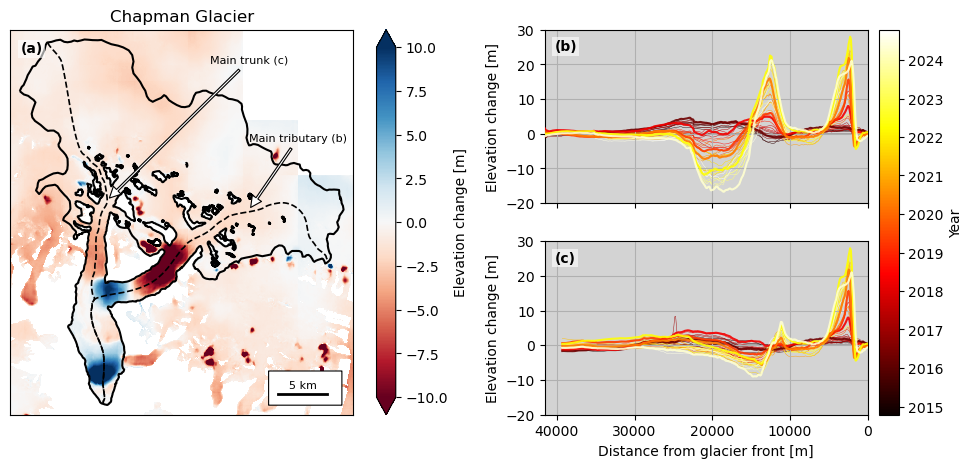

In [20]:
# Dates to highlight in the lower panel
highlight_dates = pd.to_datetime([
    "2016-04-15",
    "2018-04-15",
    "2019-04-15",
    "2020-04-15",
    "2022-04-15",
    "2024-04-15",
])

udem_ref = udem_masked_rio.sel(time = udem_masked_rio.time.values[-1]) - udem_masked_rio.sel(time = udem_masked_rio.time.values[0])


plot_surging_glacier_2line(
    df_anom1,
    distances1,
    df_anom2,
    distances2,
    udem_ref,
    chapman,
    chapman_line,
    chapman_line2_extended,
    "Chapman Glacier",
    "chapman",
    highlight_dates,
    experiment,
    projectDir
)

In [21]:
def plot_surging_glacier_movie(
    df_anom1,
    distances1,
    df_anom2,
    distances2,
    udem_masked_rio,
    udem_ref,
    glacier,
    glacierline1,
    glacierline2,
    glaciername,
    glaciernameshort,
    experiment,
    projectDir,
    fps=2,
    raster_vmin=-10,
    raster_vmax=10,
    profile_ylim=(-20, 30)
):

    # =========================================================
    # Prepare profile anomaly data
    # =========================================================
    data1 = df_anom1["udem"]
    data2 = df_anom2["udem"]

    # Use common set of times
    times1 = pd.to_datetime(data1.index)
    times2 = pd.to_datetime(data2.index)

    times = times1.union(times2).sort_values()

    time_nums = mdates.date2num(times)

    norm = mcolors.Normalize(
        vmin=time_nums.min(),
        vmax=time_nums.max()
    )

    cmap_profiles = cm.hot

    # Distance from glacier front
    distance_from_front1 = distances1[-1] - distances1
    distance_from_front2 = distances2[-1] - distances2

    # Common x-axis extent
    max_distance = distances1[-1]

    # =========================================================
    # Compute spatial U-DEM anomalies
    # Each pixel relative to its temporal mean
    # =========================================================
    # udem_ref = udem_masked_rio.mean(
    #     dim="time",
    #     skipna=True
    # )
    #udem_ref = udem_masked_rio.sel(time = udem_masked_rio.time.values[0])

    udem_anom_rio = udem_masked_rio - udem_ref

    udem_anom_rio = udem_anom_rio.squeeze(drop=True)

    # =========================================================
    # Create figure
    # =========================================================
    fig = plt.figure(figsize=(8, 12))

    gs = gridspec.GridSpec(
        nrows=4,
        ncols=1,
        height_ratios=[1, 1, 1, 1],
        hspace=0.28
    )

    # =========================================================
    # Panel (a): animated raster
    # =========================================================
    ax1 = fig.add_subplot(gs[0:2])

    first_raster = udem_anom_rio.sel(
        time=times[0],
        method="nearest"
    ).squeeze(drop=True)

    extent = [
        float(first_raster.x.min()),
        float(first_raster.x.max()),
        float(first_raster.y.min()),
        float(first_raster.y.max())
    ]

    im = ax1.imshow(
        first_raster.values,
        extent=extent,
        origin="upper",
        cmap="RdBu_r",
        vmin=raster_vmin,
        vmax=raster_vmax
    )

    cbar1 = fig.colorbar(
        im,
        ax=ax1
    )

    cbar1.set_label("Elevation anomaly [m]")

    glacier.boundary.plot(
        ax=ax1,
        color="k"
    )

    glacierline1.plot(
        ax=ax1,
        linestyle="--",
        color="k",
        linewidth=1.2
    )

    glacierline2.plot(
        ax=ax1,
        linestyle="--",
        color="k",
        linewidth=1.2
    )

    ax1.set_title(glaciername)

    ax1.set_xlim(
        glacier.geometry.total_bounds[0] - 1000,
        glacier.geometry.total_bounds[2] + 1000
    )

    ax1.set_ylim(
        glacier.geometry.total_bounds[1] - 1000,
        glacier.geometry.total_bounds[3] + 1000
    )

    ax1.set_aspect(
        "equal",
        adjustable="box",
        anchor="C"
    )

    ax1.set_xticks([])
    ax1.set_yticks([])
    ax1.set_xlabel("")
    ax1.set_ylabel("")

    ax1.text(
        0.03,
        0.94,
        "(a)",
        fontweight="bold",
        transform=ax1.transAxes,
        fontsize=10,
        bbox=dict(
            facecolor="white",
            alpha=0.6,
            edgecolor="none",
            boxstyle="square,pad=0.15"
        )
    )

    # =========================================================
    # Panel (b): accumulating profile 1
    # =========================================================
    ax2 = fig.add_subplot(gs[2])

    ax2.set_facecolor("lightgrey")

    ax2.set_xlim(
        max_distance,
        0
    )

    ax2.set_ylim(
        profile_ylim[0],
        profile_ylim[1]
    )

    ax2.set_ylabel(
        "Elevation anomaly [m]"
    )

    ax2.grid(True)

    ax2.text(
        0.03,
        0.88,
        "(b)",
        fontweight="bold",
        transform=ax2.transAxes,
        fontsize=10,
        bbox=dict(
            facecolor="white",
            alpha=0.6,
            edgecolor="none",
            boxstyle="square,pad=0.15"
        )
    )

    # =========================================================
    # Panel (c): accumulating profile 2
    # =========================================================
    ax3 = fig.add_subplot(gs[3])

    ax3.set_facecolor("lightgrey")

    ax3.set_xlim(
        max_distance,
        0
    )

    ax3.set_ylim(
        profile_ylim[0],
        profile_ylim[1]
    )

    ax3.set_xlabel(
        "Distance from glacier front [m]"
    )

    ax3.set_ylabel(
        "Elevation anomaly [m]"
    )

    ax3.grid(True)

    ax3.text(
        0.03,
        0.88,
        "(c)",
        fontweight="bold",
        transform=ax3.transAxes,
        fontsize=10,
        bbox=dict(
            facecolor="white",
            alpha=0.6,
            edgecolor="none",
            boxstyle="square,pad=0.15"
        )
    )

    # =========================================================
    # Shared profile colourbar
    # =========================================================
    sm = cm.ScalarMappable(
        norm=norm,
        cmap=cmap_profiles
    )

    sm.set_array([])

    cbar2 = fig.colorbar(
        sm,
        ax=[ax2, ax3],
        pad=0.03
    )

    cbar2.set_label("Year")

    cbar2.ax.yaxis.set_major_locator(
        mdates.YearLocator()
    )

    cbar2.ax.yaxis.set_major_formatter(
        mdates.DateFormatter("%Y")
    )

    # =========================================================
    # Date at top centre
    # =========================================================
    date_text = fig.text(
        0.5,
        0.975,
        "",
        ha="center",
        va="top",
        fontsize=16,
        fontweight="bold"
    )

    # Store profile lines already drawn
    lines1 = []
    lines2 = []

    # =========================================================
    # Animation update function
    # =========================================================
    def update(frame):

        time = pd.Timestamp(times[frame])

        # -----------------------------------------------------
        # Update upper raster
        # -----------------------------------------------------
        current_raster = udem_anom_rio.sel(
            time=time,
            method="nearest"
        ).squeeze(drop=True)

        im.set_data(
            current_raster.values
        )

        # -----------------------------------------------------
        # Fade previous profile lines
        # -----------------------------------------------------
        for line in lines1:
            line.set_alpha(0.3)
            line.set_linewidth(1.0)

        for line in lines2:
            line.set_alpha(0.3)
            line.set_linewidth(1.0)

        color = cmap_profiles(
            norm(
                mdates.date2num(time)
            )
        )

        # -----------------------------------------------------
        # Add current profile 1
        # -----------------------------------------------------
        if time in df_anom1.index:

            profile1 = df_anom1.loc[
                time,
                "udem"
            ]

            if profile1 is not None:

                try:
                    profile_array1 = np.asarray(
                        profile1,
                        dtype=float
                    )

                    if np.any(
                        np.isfinite(profile_array1)
                    ):

                        line1, = ax2.plot(
                            distance_from_front1,
                            profile_array1,
                            color=color,
                            alpha=1.0,
                            linewidth=2.5
                        )

                        lines1.append(
                            line1
                        )

                except (TypeError, ValueError):
                    pass

        # -----------------------------------------------------
        # Add current profile 2
        # -----------------------------------------------------
        if time in df_anom2.index:

            profile2 = df_anom2.loc[
                time,
                "udem"
            ]

            if profile2 is not None:

                try:
                    profile_array2 = np.asarray(
                        profile2,
                        dtype=float
                    )

                    if np.any(
                        np.isfinite(profile_array2)
                    ):

                        line2, = ax3.plot(
                            distance_from_front2,
                            profile_array2,
                            color=color,
                            alpha=1.0,
                            linewidth=2.5
                        )

                        lines2.append(
                            line2
                        )

                except (TypeError, ValueError):
                    pass

        # -----------------------------------------------------
        # Update date
        # -----------------------------------------------------
        date_text.set_text(
            time.strftime("%d %B %Y")
        )

        return (
            [im]
            + lines1
            + lines2
            + [date_text]
        )

    # =========================================================
    # Create animation
    # =========================================================
    ani = FuncAnimation(
        fig,
        update,
        frames=len(times),
        interval=1000 / fps,
        blit=False,
        repeat=False
    )

    # =========================================================
    # Save movie
    # =========================================================
    output_dir = os.path.join(
        projectDir,
        "figures"
    )

    os.makedirs(
        output_dir,
        exist_ok=True
    )

    output_file = os.path.join(
        output_dir,
        f"{experiment}_surging_{glaciernameshort}_dynamic.mp4"
    )

    writer = FFMpegWriter(
        fps=fps,
        bitrate=3000
    )

    ani.save(
        output_file,
        writer=writer,
        dpi=200
    )

    plt.close(fig)

    return ani

In [22]:
udem_ref = udem_masked_rio.sel(time = udem_masked_rio.time.values[0])

ani = plot_surging_glacier_movie(
    df_anom1,
    distances1,
    df_anom2,
    distances2,
    udem_masked_rio,
    udem_ref,
    chapman,
    chapman_line,
    chapman_line2_extended,
    "Chapman Glacier",
    "chapman",
    experiment,
    projectDir,
    fps=2
)

Requested reference: 2014-10-15 00:00:00
Using reference DEM: 2014-10-15 00:00:00
Requested reference: 2014-10-15 00:00:00
Using reference DEM: 2014-10-15 00:00:00


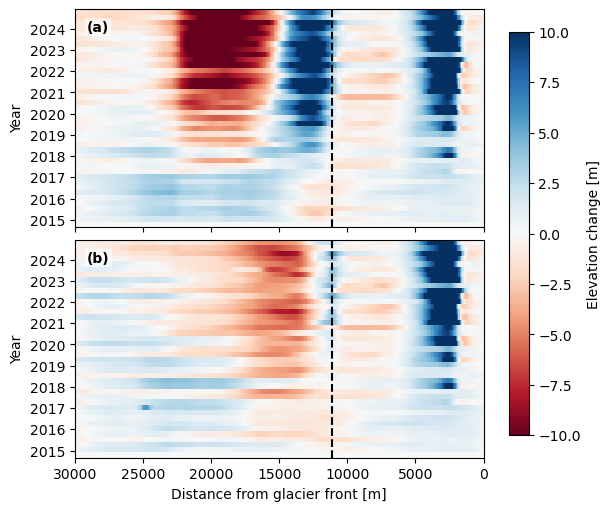

In [23]:
# ============================================================
# SETTINGS
# ============================================================

sample_spacing = 100         # metres along centreline
smooth_sigma = 2             # smoothing along profile, in samples
confluence_distance = bottom_part.length  # metres from glacier front

# Fixed reference DEM
reference_time = "2014-10-15"


# ============================================================
# 1. SAMPLE U-DEM ALONG A LINE
# ============================================================

def extract_line_profiles(udem, line_gdf, spacing=100):
    """
    Linearly interpolate U-DEM onto regularly spaced points along a LineString.

    Returns
    -------
    profiles : np.ndarray
        Shape (time, distance)

    distances_from_front : np.ndarray
        Distance from glacier front [m].

    times : pandas.DatetimeIndex
    """

    line = line_gdf.geometry.iloc[0]

    n_points = int(np.floor(line.length / spacing)) + 1

    distances_along_line = np.linspace(
        0,
        line.length,
        n_points
    )

    points = [
        line.interpolate(d)
        for d in distances_along_line
    ]

    xs = np.array([p.x for p in points])
    ys = np.array([p.y for p in points])

    profiles = []

    for t in udem.time.values:

        da_t = udem.sel(time=t)

        values = da_t.interp(
            x=("points", xs),
            y=("points", ys),
            method="linear"
        ).values

        values = np.asarray(values).squeeze()

        profiles.append(values)

    profiles = np.stack(profiles)

    # Assumption:
    # line begins upstream and ends at glacier front.
    # Therefore convert distance along line to distance from front.
    distances_from_front = (
        line.length - distances_along_line
    )

    times = pd.to_datetime(
        udem.time.values
    )

    return (
        profiles,
        distances_from_front,
        times
    )


# ============================================================
# 2. EXTRACT BOTH CENTRELINES
# ============================================================

profiles_trunk, dist_trunk, times = extract_line_profiles(
    udem_masked_rio,
    chapman_line2_extended,
    spacing=sample_spacing
)

profiles_tributary, dist_tributary, times2 = extract_line_profiles(
    udem_masked_rio,
    chapman_line,
    spacing=sample_spacing
)


# ============================================================
# 3. CALCULATE ELEVATION CHANGE RELATIVE TO FALL 2014
# ============================================================

def calculate_reference_change(
    profiles,
    times,
    reference_time="2014-10-15"
):
    """
    Calculate elevation change relative to a fixed reference DEM.

    dh(t) = h(t) - h(reference_time)

    Returns
    -------
    dh : np.ndarray
        Elevation change relative to the reference profile.

    times : pandas.DatetimeIndex

    ref_idx : int
        Index of reference timestep.

    actual_reference_time : pandas.Timestamp
        Actual timestep selected.
    """

    reference_time = pd.Timestamp(
        reference_time
    )

    # Find timestep closest to requested reference date
    ref_idx = np.argmin(
        np.abs(
            times - reference_time
        )
    )

    actual_reference_time = times[ref_idx]

    print(
        f"Requested reference: {reference_time}"
    )

    print(
        f"Using reference DEM: {actual_reference_time}"
    )

    # Extract reference profile
    ref_profile = profiles[
        ref_idx,
        :
    ]

    # Calculate elevation change
    dh = (
        profiles -
        ref_profile[np.newaxis, :]
    )

    return (
        dh,
        times,
        ref_idx,
        actual_reference_time
    )


dh_trunk, times_dh, ref_idx_trunk, ref_time_trunk = (
    calculate_reference_change(
        profiles_trunk,
        times,
        reference_time=reference_time
    )
)


dh_tributary, times_dh2, ref_idx_tributary, ref_time_tributary = (
    calculate_reference_change(
        profiles_tributary,
        times2,
        reference_time=reference_time
    )
)


# ============================================================
# 4. OPTIONAL: SMOOTH ALONG PROFILE
# ============================================================

def smooth_profiles(
    data,
    sigma=2
):
    """
    Smooth each profile along the spatial dimension.

    NaNs are handled using weighted Gaussian smoothing.
    """

    smoothed = np.full_like(
        data,
        np.nan,
        dtype=float
    )

    for i in range(
        data.shape[0]
    ):

        values = data[i]

        valid = np.isfinite(
            values
        )

        if valid.sum() < 3:
            continue

        values0 = np.where(
            valid,
            values,
            0
        )

        numerator = gaussian_filter1d(
            values0,
            sigma=sigma,
            mode="nearest"
        )

        denominator = gaussian_filter1d(
            valid.astype(float),
            sigma=sigma,
            mode="nearest"
        )

        result = (
            numerator /
            np.where(
                denominator > 0,
                denominator,
                np.nan
            )
        )

        smoothed[i] = result

    return smoothed


dh_trunk_smooth = smooth_profiles(
    dh_trunk,
    sigma=smooth_sigma
)

dh_tributary_smooth = smooth_profiles(
    dh_tributary,
    sigma=smooth_sigma
)


# ============================================================
# 5. CALCULATE SHARED COLOR SCALE
# ============================================================

all_values = np.concatenate([
    dh_trunk_smooth.ravel(),
    dh_tributary_smooth.ravel()
])

all_values = all_values[
    np.isfinite(all_values)
]

vmax = np.nanpercentile(
    np.abs(all_values),
    98
)

vmax = 10

vmin = -vmax


# ============================================================
# FIGURE 1
# HOVMÖLLER DIAGRAMS
# ============================================================

fig, axes = plt.subplots(
    2,
    1,
    figsize=(6, 5),
    sharex=True,
    constrained_layout=True
)


# ------------------------------------------------------------
# Tributary
# ------------------------------------------------------------

mesh1 = axes[0].pcolormesh(
    dist_tributary,
    times_dh2,
    dh_tributary_smooth,
    shading="auto",
    cmap="RdBu",
    vmin=vmin,
    vmax=vmax
)

# Confluence
axes[0].axvline(
    confluence_distance,
    color="black",
    linestyle="--",
    linewidth=1.5
)


axes[0].set_ylabel(
    "Year"
)

# axes[0].set_title(
#     "(a) Tributary → shared lower trunk"
# )

axes[0].invert_xaxis()

axes[0].yaxis.set_major_locator(
    mdates.YearLocator()
)

axes[0].yaxis.set_major_formatter(
    mdates.DateFormatter("%Y")
)


# ------------------------------------------------------------
# Main trunk
# ------------------------------------------------------------

mesh2 = axes[1].pcolormesh(
    dist_trunk,
    times_dh,
    dh_trunk_smooth,
    shading="auto",
    cmap="RdBu",
    vmin=vmin,
    vmax=vmax
)

# Confluence
axes[1].axvline(
    confluence_distance,
    color="black",
    linestyle="--",
    linewidth=1.5
)


axes[1].set_ylabel(
    "Year"
)

axes[1].set_xlabel(
    "Distance from glacier front [m]"
)

# axes[1].set_title(
#     "(b) Main trunk → shared lower trunk"
# )

axes[1].invert_xaxis()

axes[1].yaxis.set_major_locator(
    mdates.YearLocator()
)

axes[1].yaxis.set_major_formatter(
    mdates.DateFormatter("%Y")
)

axes[0].set_xlim(30000,0)
axes[1].set_xlim(30000,0)
axes[0].text(
        0.03,
        0.9,
        "(a)",
        fontweight="bold",
        transform=axes[0].transAxes,
        fontsize=10,
        bbox=dict(
            facecolor="white",
            alpha=0.6,
            edgecolor="none",
            boxstyle="square,pad=0.15"
        )
    )

axes[1].text(
        0.03,
        0.9,
        "(b)",
        fontweight="bold",
        transform=axes[1].transAxes,
        fontsize=10,
        bbox=dict(
            facecolor="white",
            alpha=0.6,
            edgecolor="none",
            boxstyle="square,pad=0.15"
        )
    )
# ------------------------------------------------------------
# Colorbar
# ------------------------------------------------------------

cbar = fig.colorbar(
    mesh2,
    ax=axes,
    shrink=0.9
)

cbar.set_label(
    "Elevation change [m]"
)

# -----------------------------
fig.savefig(
    f"{projectDir}/figures/"
    f"{experiment}_surging_chapman_hovmoller.png",
    dpi=300,
    bbox_inches="tight"
)